In [3]:
!pip install yfinance


In [5]:
import yfinance as yf
import pandas as pd

# NSE stock list (can expand later)
stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS"]

results = []

for stock in stocks:
    data = yf.download(stock, period="6mo")

    support = data['Low'].min()
    resistance = data['High'].max()
    latest_price = data['Close'].iloc[-1]

    volume_avg = data['Volume'].mean()
    latest_volume = data['Volume'].iloc[-1]

    if latest_price > resistance * 0.95:
        signal = "Possible Breakout"
    elif latest_price < support * 1.05:
        signal = "Possible Reversal"
    else:
        signal = "Neutral"

    if latest_volume > volume_avg:
        volume_signal = "High Volume Activity"
    else:
        volume_signal = "Normal Volume"

    results.append([stock, latest_price, support, resistance, signal, volume_signal])

df = pd.DataFrame(results, columns=["Stock", "Price", "Support", "Resistance", "Signal", "Volume Activity"])

df

/tmp/ipykernel_10778/1577409684.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, period="6mo")
[*********************100%***********************]  1 of 1 completed


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [6]:
!pip install yfinance


In [7]:
import yfinance as yf
import pandas as pd

stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS"]

results = []

for stock in stocks:

    data = yf.download(stock, period="6mo")

    # Skip empty data
    if data.empty:
        continue

    support = float(data['Low'].min())
    resistance = float(data['High'].max())
    latest_price = float(data['Close'].iloc[-1])

    volume_avg = float(data['Volume'].mean())
    latest_volume = float(data['Volume'].iloc[-1])

    if latest_price > resistance * 0.95:
        signal = "Possible Breakout"
    elif latest_price < support * 1.05:
        signal = "Possible Reversal"
    else:
        signal = "Neutral"

    if latest_volume > volume_avg:
        volume_signal = "High Volume Activity"
    else:
        volume_signal = "Normal Volume"

    results.append([
        stock,
        latest_price,
        support,
        resistance,
        signal,
        volume_signal
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Stock",
        "Price",
        "Support",
        "Resistance",
        "Signal",
        "Volume Activity"
    ]
)

df

/tmp/ipykernel_10778/458151029.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, period="6mo")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10778/458151029.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  support = float(data['Low'].min())
/tmp/ipykernel_10778/458151029.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  resistance = float(data['High'].max())
/tmp/ipykernel_10778/458151029.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_price = float(data['Close'].iloc[-1])
/tmp/ipykernel_10778/458151029.py:20: FutureWarning: Calling float on a single element Series is deprecat

,Stock,Price,Support,Resistance,Signal,Volume Activity
0,RELIANCE.NS,1348.099976,1307.000000,1611.800049,Possible Reversal,High Volume Activity
1,TCS.NS,2389.800049,2348.000000,3350.000000,Possible Reversal,High Volume Activity
2,INFY.NS,1269.699951,1215.099976,1728.000000,Possible Reversal,High Volume Activity
3,HDFCBANK.NS,756.200012,741.049988,1020.500000,Possible Reversal,High Volume Activity
4,ICICIBANK.NS,1233.800049,1218.099976,1445.000000,Possible Reversal,High Volume Activity


In [8]:
def explain_signal(signal):

    if signal == "Possible Breakout":
        return "Stock nearing breakout zone. Upward momentum expected."

    elif signal == "Possible Reversal":
        return "Stock near support level. Possible bounce opportunity."

    else:
        return "Stock sideways. Wait for confirmation signal."


df["Explanation"] = df["Signal"].apply(explain_signal)

df

,Stock,Price,Support,Resistance,Signal,Volume Activity,Explanation
0,RELIANCE.NS,1348.099976,1307.000000,1611.800049,Possible Reversal,High Volume Activity,Stock near support level. Possible bounce oppo...
1,TCS.NS,2389.800049,2348.000000,3350.000000,Possible Reversal,High Volume Activity,Stock near support level. Possible bounce oppo...
2,INFY.NS,1269.699951,1215.099976,1728.000000,Possible Reversal,High Volume Activity,Stock near support level. Possible bounce oppo...
3,HDFCBANK.NS,756.200012,741.049988,1020.500000,Possible Reversal,High Volume Activity,Stock near support level. Possible bounce oppo...
4,ICICIBANK.NS,1233.800049,1218.099976,1445.000000,Possible Reversal,High Volume Activity,Stock near support level. Possible bounce oppo...


/tmp/ipykernel_10778/2558458163.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, period="6mo")
[*********************100%***********************]  1 of 1 completed


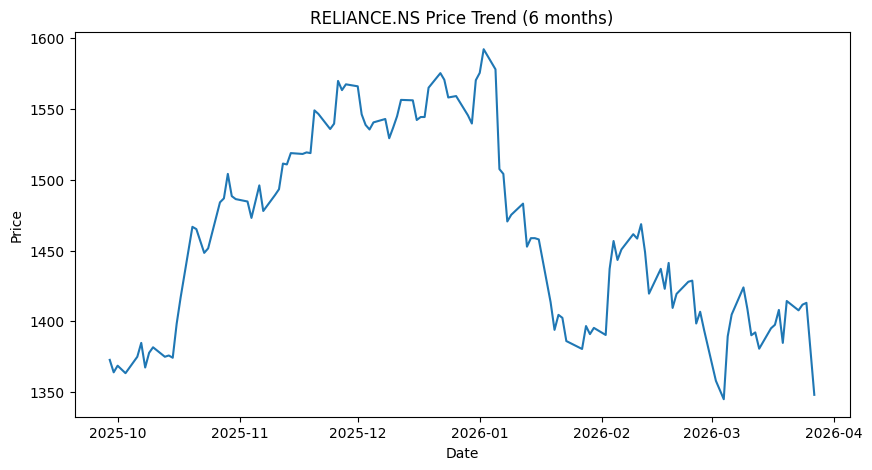

In [9]:
import matplotlib.pyplot as plt

stock = "RELIANCE.NS"

data = yf.download(stock, period="6mo")

plt.figure(figsize=(10,5))
plt.plot(data["Close"])

plt.title(f"{stock} Price Trend (6 months)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()